1.  Take an image of something you like and convert it to a greyscale image.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('nausica.jpg')
img_grey = cv2.imread('nausica.jpg', cv2.IMREAD_GRAYSCALE)


# Q1
Obtain the frequency distribuAon of the pixel intensity

In [2]:
#print(img)
cv2.imshow('title', img_grey)
cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/aswin/ml_env/lib/python3.11/site-packages/cv2/qt/plugins"


In [ ]:
x=height, width = img_grey.shape
print(x)
print(img_grey) #intensity array of greyscale image in 2D

In [ ]:
pixels_1d = img.flatten()
print(pixels_1d) # 1d array of intensities
freq = np.bincount(pixels_1d) #counts how many times a value appears
# in 0 to 255 

In [ ]:
intensity = np.arange(len(freq)) # to have 0 to 255 in order ascending
plt.bar(intensity, freq)
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.title('pixel intensity hist')
plt.show()

verify that the sum of all histogram frequencies is same as the total number of
• Plot the histogram of the intensity values.
pixels in the image.

In [7]:
print(img.size)
print(np.sum(freq))
# yes the sum of frequencies are equivalent to the number of pixels.
# freq sum is adding up no. of values in each bin.

921600
921600


# Q2
Select matrix as image and then display it to see the changes. This will help
you to understand the Intensity array and also how to manipulate the image.

In [46]:
img=cv2.imread('rohan.jpg', cv2.IMREAD_GRAYSCALE)
copy=img.copy()

In [47]:
out = img.copy()

x, y = 50, 50
n = 100

# convert to int16 then back to 8 after clipping
roi = out[y:y+n, x:x+n].astype(np.int16)
roi = np.clip(roi + 40, 0, 255)
out[y:y+n, x:x+n] = roi.astype(np.uint8)

# done
cv2.imshow('Original', img)
cv2.imshow('Brightened', out)
cv2.waitKey(0)
cv2.destroyAllWindows()


# Q3. 
Covert the following image into a grey scale image. Carryout reflection operation of
pixel intensities along the vertical axis a) on the LHS edge of the image b) on the RHS
of the image and c) at the center of the image. Save the image obtained by each of
the reflection operation and display it on the screen.

In [20]:
img2=cv2.imread('two_people.png')
# flip the image along RHS or LHS axis
h, w, c = img2.shape 
flipped = np.zeros((h,w,c), dtype=img2.dtype)

for i in range(w):
    flipped[:, w-1-i,:] = img2[:, i,:] # since width starts from 0

In [29]:
#reflect image
cv2.imshow('stock',img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [43]:
# reflect along the central axis
h, w, c =img2.shape
print(h,w,c)
wid = int(w)
mid = int(w/2)

print(mid,wid)
l_side = np.zeros((h,w,c), dtype=img2.dtype)
r_side = np.zeros((h,w,c), dtype=img2.dtype)


for i in range(0,mid):
    tracer=(mid-i-1)
    l_side[:,i,:] = img2[:,tracer,:]
for i in range(mid,wid):
    tracer=(wid-mid-i)
    r_side[:,i,:] = img2[:,tracer,:]

mid_ref=l_side+r_side

457 680 3
340 680


In [45]:
cv2.imshow('stock',mid_ref)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Q4
Take a clean A4 size paper without any wrinkles on it. Draw a proper circle of radius
50 mm with a pencil and properly darken the inner area of the circle. Take two
photographs of the shaded circle using your mobile camera say from a distance of
exactly 50 cm and 80 cm. Translate these two images to greyscale images and then
obtain the greyscale intensity histograms of both the images. Obtain as many
inferences as possible using these images.

In [ ]:
d50=cv2.imread('50.jpeg',cv2.IMREAD_GRAYSCALE)
d80=cv2.imread('80.jpeg',cv2.IMREAD_GRAYSCALE)
d50_1d = d50.flatten()
d80_1d = d80.flatten()
print(d50_1d) # 1d array of intensities
d50_freq = np.bincount(d50_1d) 
d80_freq = np.bincount(d80_1d)

In [ ]:
d50_int = np.arange(len(d50_freq)) # to have 0 to 255 in order ascending
plt.bar(d50_int, d50_freq)
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.title('pixel intensity hist')
plt.show()
plt.savefig("d50_hist.png")

In [ ]:
d80_int = np.arange(len(d80_freq)) # to have 0 to 255 in order ascending
plt.bar(d80_int, d80_freq)
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.title('pixel intensity hist')
plt.show()

In [ ]:
# Grey scale converted

cv2.imshow('stock',d50)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imshow('stock',d80)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Inferences
The 50 cm away image has higher intensity in the 120 to 180 intensities which are closer to white. This means most of the background is white. It also have a small broad peak in 0 to 50 region. This is representing the black circle. And the broadness implies higher contrast of that region with respect to the surrounding. While the white region is having 3 sharp peaks. This shows low constrast among the multiple shades of gray.

For the 80cm away image. The broad black peak is even smaller. It's because of the black region being smaller compared to the white background. And similarly the 3 gray peaks are there for each gray shade, with less contrast, indicated by sharper peaks. It also leaks out into under 100 making while the region at 200 is more sharp. 
This might be due to the more background or white/gray region occupying the image.

# Q5
Explore the possible way to relate optical image and physical parameters of objects
in the image.

960 1280


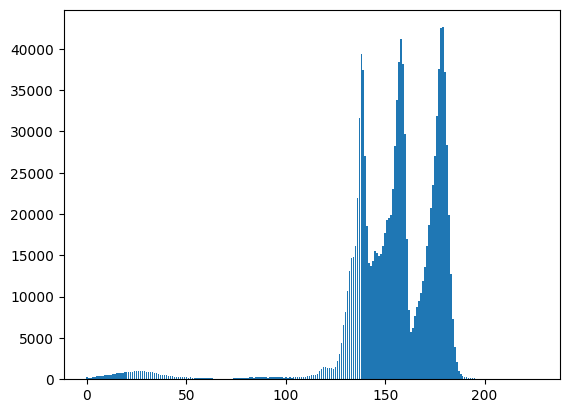

In [80]:
d50=cv2.imread('50.jpeg',cv2.IMREAD_GRAYSCALE)
d80=cv2.imread('80.jpeg',cv2.IMREAD_GRAYSCALE)

pixels = d50.flatten()
d50_freq = np.bincount(pixels)
intensity =np.arange(len(d50_freq))
hist = plt.bar(intensity,d50_freq)

# convert to b/w
# seems like thresholding cant be done on histograms, but directly on img

## THRESHOLDING
d50_bw = d50.copy()
h, w = d50.shape
print(h,w)
for i in range(h):
    for j in range(w):
        if d50[i,j]>=70:
            d50_bw[i,j] = 0
        else:
            d50_bw[i,j] = 255

# Detecting the diameter

In [105]:
cv2.imshow('stock',d50_bw)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Q6
 Propose the method to get focal length of mobile camera.

In [82]:
for i in range

Number of Contours Found = 93


In [100]:
cv2.imshow('stock',edged)
cv2.waitKey(0)
cv2.destroyAllWindows()